
170498071/170498071 [==============================] - 178s 1us/step



Epoch 1/10


125/125 [==============================] - 6s 32ms/step - loss: 0.6169 - accuracy: 0.6488 - val_loss: 0.5054 - val_accuracy: 0.7625
Epoch 2/10
125/125 [==============================] - 4s 29ms/step - loss: 0.4799 - accuracy: 0.7770 - val_loss: 0.3788 - val_accuracy: 0.8435
Epoch 3/10
125/125 [==============================] - 4s 29ms/step - loss: 0.3704 - accuracy: 0.8441 - val_loss: 0.3468 - val_accuracy: 0.8455
Epoch 4/10
125/125 [==============================] - 4s 29ms/step - loss: 0.3224 - accuracy: 0.8643 - val_loss: 0.3261 - val_accuracy: 0.8555
Epoch 5/10
125/125 [==============================] - 4s 31ms/step - loss: 0.2745 - accuracy: 0.8894 - val_loss: 0.2793 - val_accuracy: 0.8770
Epoch 6/10
125/125 [==============================] - 4s 31ms/step - loss: 0.2362 - accuracy: 0.9040 - val_loss: 0.2531 - val_accuracy: 0.8940
Epoch 7/10
125/125 [==============================] - 4s 30ms/step 

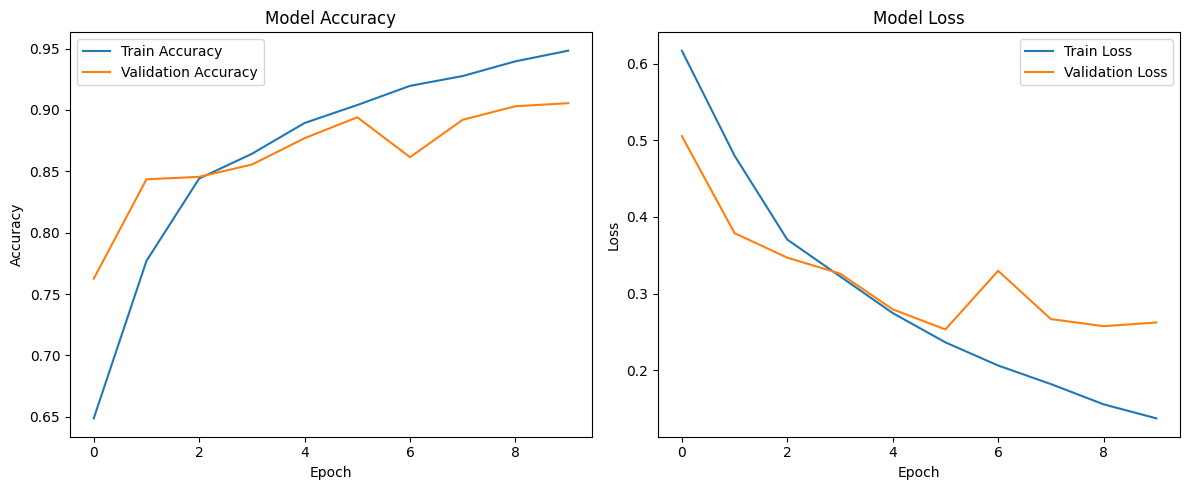

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Step 1: Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Step 2: Filter out only the airplane (class 0) and ship (class 8) images
# These two classes will be used for binary classification
classes_to_keep = [0, 8]   # airplane = 0, ship = 8

# Create filter for training and test sets
train_filter = np.isin(y_train, classes_to_keep).flatten()
test_filter = np.isin(y_test, classes_to_keep).flatten()

# Apply the filter
x_train = x_train[train_filter]
y_train = y_train[train_filter]
x_test = x_test[test_filter]
y_test = y_test[test_filter]

# Step 3: Convert labels from original class-based
# airplane (0) -> horizontal (0)
# ship (8) -> vertical (1)
y_train = np.where(y_train == 0, 0, 1)
y_test = np.where(y_test == 0, 0, 1)

# Step 4: Normalize pixel values between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Step 5: Convert labels to one-hot encoding
y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

# Step 6: Define the CNN model
model = Sequential()

# First convolutional layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolutional layer
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Dropout layer
model.add(Dropout(0.5))

# Output layer
model.add(Dense(2, activation='softmax'))

# Step 7: Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 8: Train the model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# Step 9: Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 288ms/step


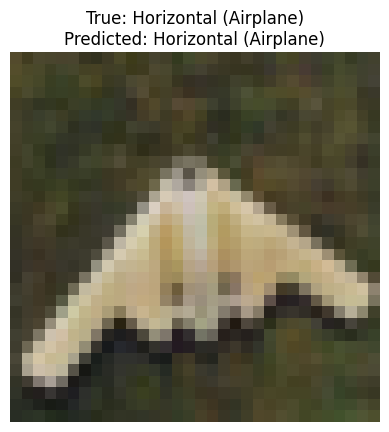

In [2]:
# Import necessary libraries for visualization
import matplotlib.pyplot as plt
import numpy as np

# Function to display the image and prediction result
def display_sample_prediction(index):
    # Get the test image and corresponding label
    image = x_test[index]
    true_label = y_test[index]

    # Predict the class using the trained model
    prediction = model.predict(np.expand_dims(image, axis=0))

    # Convert the prediction to a class label (0 or 1)
    predicted_label = np.argmax(prediction, axis=1)[0]

    # Convert the true label from one-hot encoding to integer
    true_label_idx = np.argmax(true_label)

    # Class names
    class_names = ['Horizontal (Airplane)', 'Vertical (Ship)']

    # Display the image
    plt.imshow(image)
    plt.title(f"True: {class_names[true_label_idx]}\nPredicted: {class_names[predicted_label]}")
    plt.axis('off')
    plt.show()

# Pick any index from test set
sample_index = 10
display_sample_prediction(sample_index)